# S1f. The field-of-view series: 64 → 96 → 128 µm

*Inference filter: flat 10 cells, matching training. See the note under Featurise —
this setting favours the largest FOV.*

The three configs that share a rasterisation of 2.0 µm/px and differ only in how much
tissue a window covers. Run through every downstream step together: featurisation →
Leiden → UMAP → tissue maps → cluster composition → border diagnostic → biology
separation → the composition baseline.

| | FOV | global/local | cells per window | windows | final loss |
|---|---|---|---|---|---|
| **E** | 64 µm | 32 / 24 | ~26 | 1078 | 2.52 |
| **F** | 96 µm | 48 / 32 | ~57 | 499 | 2.15 |
| **A** | 128 µm | 64 / 48 | ~101 | 272 | 0.865 |

**The question.** The six-way sweep found coherence rising monotonically across this
series, then falling at 192 µm — so 128 µm is an interior optimum. But *how* it rises
matters. If the climb is gradual, window size is a smooth trade-off and 112 µm might
beat 128. If it is a step, there is a threshold below which the model cannot represent
arrangement at all, and the design question changes from "tune it" to "clear it".

F is the config that decides this, because it sits between the two.

The 192 µm configs are excluded on purpose: they change resolution or introduce border
clusters, and this notebook isolates scale. For all six see
`S1.window_size_sweep.ipynb`; for the A-vs-E pair in isolation see
`S1e.compare_A_vs_E.ipynb`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import imc_tm

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
pd.set_option("display.width", 250)

SERIES      = ["E_fov64_px2.0", "F_fov96_px2.0", "A_fov128_px2.0"]   # ascending FOV
RESOLUTION  = 1.0
N_NEIGHBORS = 15
SEED        = 0
INFERENCE_THR = 10    # flat, matching the TRAINING value -- keep every tile we can
FRACTION      = 0.5   # unused now; the fov-scaled variant is one edit away
SHORT       = {n: n.split("_")[0] for n in SERIES}

print(imc_tm.compat_summary())
print()
for n in SERIES:
    s = imc_tm.sweep_spec(n)
    thr = INFERENCE_THR
    print(f"{n:<16s} FOV {s['fov_um']:3d} um | global {s['global_size']:3d} / local {s['local_size']:2d} "
          f"| analysis filter {thr:3d} cells | trained: {imc_tm.sweep_checkpoint(n).is_file()}")

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt

E_fov64_px2.0    FOV  64 um | global  32 / local 24 | analysis filter  10 cells | trained: True
F_fov96_px2.0    FOV  96 um | global  48 / local 32 | analysis filter  10 cells | trained: True
A_fov128_px2.0   FOV 128 um | global  64 / local 48 | analysis filter  10 cells | trained: True


## Loss curves

Identical 200-epoch schedules, so these are directly comparable. Loss falls steeply
with window occupancy — which is worth stating plainly because it is **not** a quality
signal. The DINO objective simply gets noisier when fewer cells are available to match
across two crops of the same window. Ranking the sweep on loss selects the wrong config.

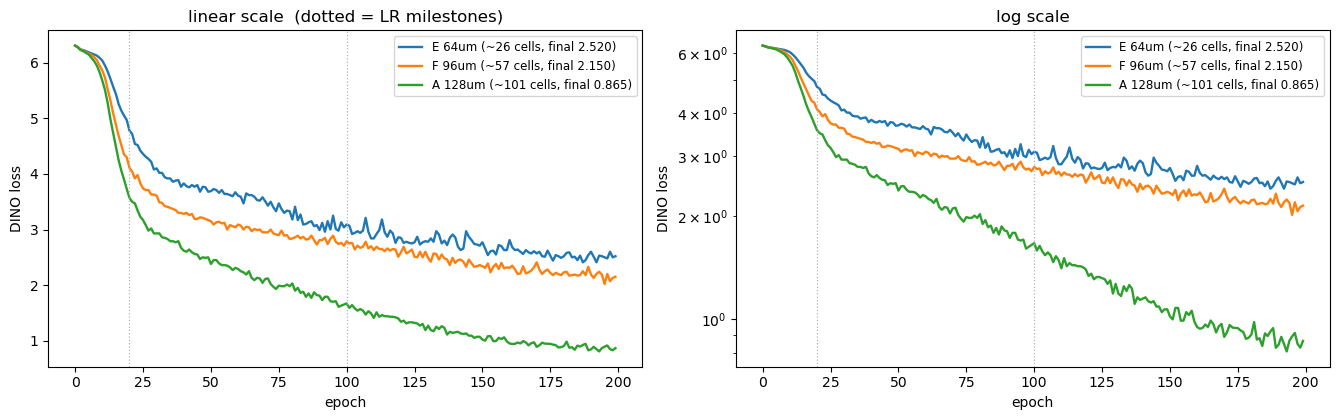

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
CELLS = {"E_fov64_px2.0": 26, "F_fov96_px2.0": 57, "A_fov128_px2.0": 101}
for ax, logy in zip(axes, [False, True]):
    for n in SERIES:
        lc = imc_tm.read_loss_curve(n)
        if len(lc):
            ax.plot(lc["epoch"], lc["loss"], lw=1.7,
                    label=f"{SHORT[n]} {imc_tm.sweep_spec(n)['fov_um']}um "
                          f"(~{CELLS[n]} cells, final {lc['loss'].iloc[-1]:.3f})")
    ax.axvline(20, color="0.7", lw=0.9, ls=":"); ax.axvline(100, color="0.7", lw=0.9, ls=":")
    ax.set_xlabel("epoch"); ax.set_ylabel("DINO loss"); ax.legend(fontsize=8.5)
    ax.set_title("log scale" if logy else "linear scale  (dotted = LR milestones)")
    if logy: ax.set_yscale("log")
plt.tight_layout()

## Featurise and cluster

Tiled windows, no overlap, seeded per ROI. The analysis filter is a **flat 10 cells,
matching the training value** — every tile the cropper can produce is kept.

**Read the cross-FOV comparison with that in mind.** A flat threshold is not a flat
criterion: 10 cells is 38% of the expected occupancy of a 64 µm window but only 10% of
a 128 µm one, so it is *relatively most permissive at the largest FOV*. Border and
sparse windows inflate spatial coherence, so this setting biases the comparison
**toward A**. The `fov_scaled_threshold` variant (13 / 29 / 52 cells = 0.5× expected)
equalises the criterion and is the fair cross-FOV test; this one shows what deployment
looks like when nothing is discarded.

It also cannot equalise *count* — a smaller window tiles the same tissue more times.

Slow cell, ~5–8 min.

In [3]:
adatas = imc_tm.load_all_anndata(imc_tm.SWEEP_H5AD_DIR)
ROIS = sorted(adatas)
res, clus, thrs = {}, {}, {}
for n in SERIES:
    spec = imc_tm.sweep_spec(n)
    cfg = imc_tm.sweep_config_dict(spec)
    thrs[n] = INFERENCE_THR
    cfg["n_element_min_for_crop"] = thrs[n]
    model = imc_tm.load_model(imc_tm.sweep_checkpoint(n))
    dm = imc_tm.make_datamodule(cfg)
    res[n] = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=0.0, seed=SEED, verbose=False)
    clus[n] = imc_tm.cluster_embedding(res[n]["features"], n_neighbors=N_NEIGHBORS,
                                       resolution=RESOLUTION, seed=SEED)
    print(f"{n:<16s} {len(res[n]['roi']):5d} windows -> "
          f"{len(np.unique(clus[n]['labels'])):2d} clusters")
    del model, dm

# glasbey_dark -- see imc_tm.cluster_palette
COLORS = {n: imc_tm.cluster_palette(labels=sorted(np.unique(clus[n]["labels"]))) for n in SERIES}
print("cluster palette:", imc_tm.cluster_palette_source())

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/sta

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


...

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


A_fov128_px2.0     356 windows ->  9 clusters
cluster palette: colorcet.glasbey_dark


## Metrics, and the two corrections they need

`spatial_coherence_z` is shown only for completeness. It divides by a null SD that
shrinks as ~1/√N, so it grows as ~√N at a fixed effect — and this series spans 272 to
1078 windows. `coherence_kappa` is N-free. `kappa_norm` further divides by each
config's **geometric ceiling**: what a perfect model would score on that window grid,
which is much higher at small FOV because a fixed physical domain spans more windows.

In [4]:
BIO_IDX = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]
def bio_frac(comp):
    b = np.asarray(comp)[:, BIO_IDX]
    return b / np.clip(b.sum(axis=1, keepdims=True), 1e-9, None)

DOMAINS = [400.0, 600.0, 800.0]
rows = []
for n in SERIES:
    m = imc_tm.window_metrics(res[n], clus[n]["labels"], k=4, n_perm=200, seed=SEED)
    lab_c = imc_tm.cluster_embedding(bio_frac(res[n]["composition"]), n_neighbors=N_NEIGHBORS,
                                     resolution=RESOLUTION, seed=SEED)["labels"]
    mc = imc_tm.window_metrics(res[n], lab_c, k=4, n_perm=200, seed=SEED)
    row = {"config": SHORT[n], "FOV_um": imc_tm.sweep_spec(n)["fov_um"],
           "cells_per_win": CELLS[n], "n_windows": m["n_windows"],
           "n_clusters": m["n_clusters"], "kappa": m["coherence_kappa"],
           "z": m["spatial_coherence_z"], "kappa_comp": mc["coherence_kappa"],
           "gain_x": m["coherence_kappa"] / max(mc["coherence_kappa"], 1e-9),
           "roi_mixing": m["roi_mixing"], "roimix_comp": mc["roi_mixing"]}
    for D in DOMAINS:
        row[f"norm{D:.0f}"] = m["coherence_kappa"] / imc_tm.coherence_ceiling(
            res[n]["centers_um"], res[n]["roi"], D)
    rows.append(row)
met = pd.DataFrame(rows).set_index("config")
display(met.style.format(precision=3))

,FOV_um,cells_per_win,n_windows,n_clusters,kappa,z,kappa_comp,gain_x,roi_mixing,roimix_comp,norm400,norm600,norm800
config,,,,,,,,,,,,,
E,64,26,1134,16,0.110,17.945,0.077,1.434,0.887,0.914,0.144,0.132,0.130
F,96,57,575,14,0.154,15.834,0.123,1.257,0.854,0.913,0.236,0.205,0.199
A,128,101,356,9,0.404,26.605,0.159,2.532,0.771,0.887,0.727,0.595,0.566


## Is the climb smooth or a step?

The decisive panel. `gain_x` is coherence relative to clustering the raw cell-type
count vector **on the same window grid** — so grid geometry cancels exactly, and no
assumption about tissue domain size enters. It asks what the network added over an
8-number summary anyone could compute without one.

If window size were a smooth trade-off, F at 96 µm should land between E and A.

64um  -> 96um : gain 1.43x -> 1.26x   (-0.18) for +31 cells/window
96um  -> 128um: gain 1.26x -> 2.53x   (+1.28) for +44 cells/window

AMBIGUOUS -- the two steps disagree in sign; do not read a trend from three points.


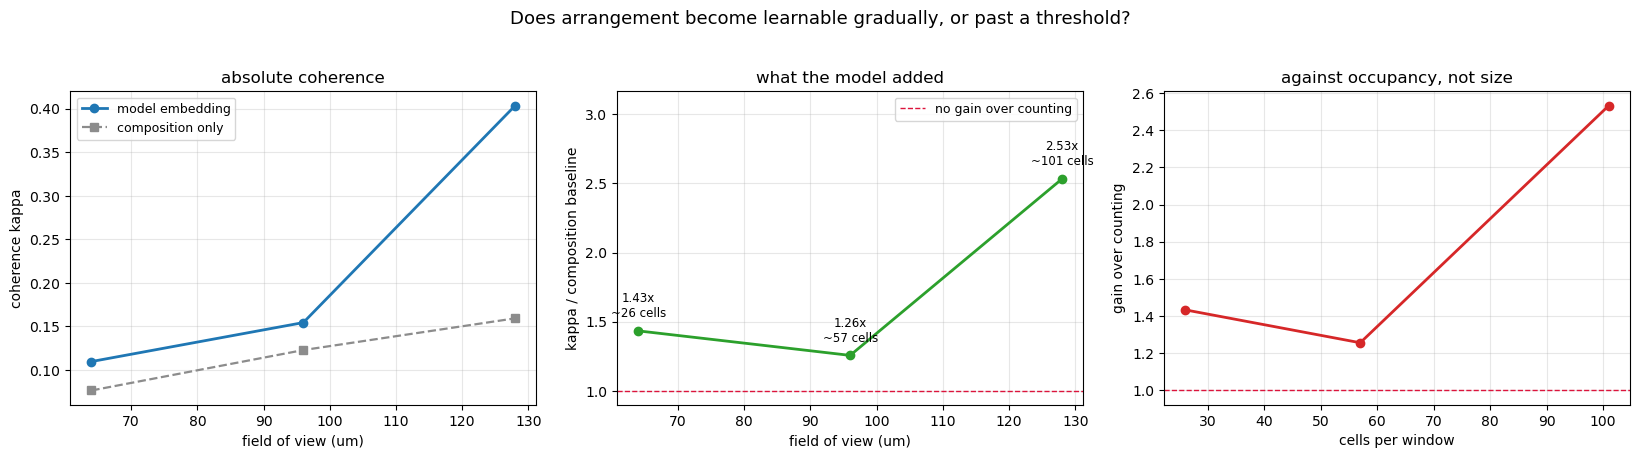

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
fovs = met["FOV_um"].values
cells = met["cells_per_win"].values

axes[0].plot(fovs, met["kappa"], "-o", lw=2, color="C0", label="model embedding")
axes[0].plot(fovs, met["kappa_comp"], "--s", lw=1.6, color="0.55", label="composition only")
axes[0].set_xlabel("field of view (um)"); axes[0].set_ylabel("coherence kappa")
axes[0].set_title("absolute coherence"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(fovs, met["gain_x"], "-o", lw=2, color="C2")
axes[1].axhline(1.0, color="crimson", lw=1, ls="--", label="no gain over counting")
for x, y, c in zip(fovs, met["gain_x"], cells):
    axes[1].annotate(f"{y:.2f}x\n~{c} cells", (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8.5)
axes[1].set_xlabel("field of view (um)"); axes[1].set_ylabel("kappa / composition baseline")
axes[1].set_ylim(0.9, max(met["gain_x"]) * 1.25)
axes[1].set_title("what the model added"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(cells, met["gain_x"], "-o", lw=2, color="C3")
axes[2].axhline(1.0, color="crimson", lw=1, ls="--")
axes[2].set_xlabel("cells per window"); axes[2].set_ylabel("gain over counting")
axes[2].set_title("against occupancy, not size"); axes[2].grid(alpha=0.3)
plt.suptitle("Does arrangement become learnable gradually, or past a threshold?", y=1.03, fontsize=13)
plt.tight_layout()

lo, mid, hi = met["gain_x"].values
d1 = met["cells_per_win"].iloc[1] - met["cells_per_win"].iloc[0]
d2 = met["cells_per_win"].iloc[2] - met["cells_per_win"].iloc[1]
print(f"64um  -> 96um : gain {lo:.2f}x -> {mid:.2f}x   ({mid - lo:+.2f}) for {d1:+d} cells/window")
print(f"96um  -> 128um: gain {mid:.2f}x -> {hi:.2f}x   ({hi - mid:+.2f}) for {d2:+d} cells/window")
print()
# Deliberately NOT reported as a ratio of the two deltas: the first is ~0, so that
# ratio is a division by noise and would read as a precise effect it is not.
if abs(mid - lo) < 0.10 and (hi - mid) > 0.50:
    print("STEP-LIKE. Widening the window from 64 to 96 um bought nothing measurable,")
    print("while the next step bought most of the total gain. Note this is a step in")
    print("what the MODEL adds -- absolute coherence did rise from 64 to 96 um, but the")
    print("composition baseline rose just as much, so nothing new was learned.")
elif (hi - mid) > 0 and (mid - lo) > 0:
    print("GRADUAL. Both steps bought gain, so window size is a smooth trade-off here")
    print("and an intermediate FOV may be worth testing.")
else:
    print("AMBIGUOUS -- the two steps disagree in sign; do not read a trend from three points.")

## UMAPs

Cluster, ROI of origin, and dominant biology channel. Bear the point counts in mind
when reading these: 1078 points render as structure where 272 render as blobs, so
apparent tidiness is not evidence on its own — the N-matched tests below are.

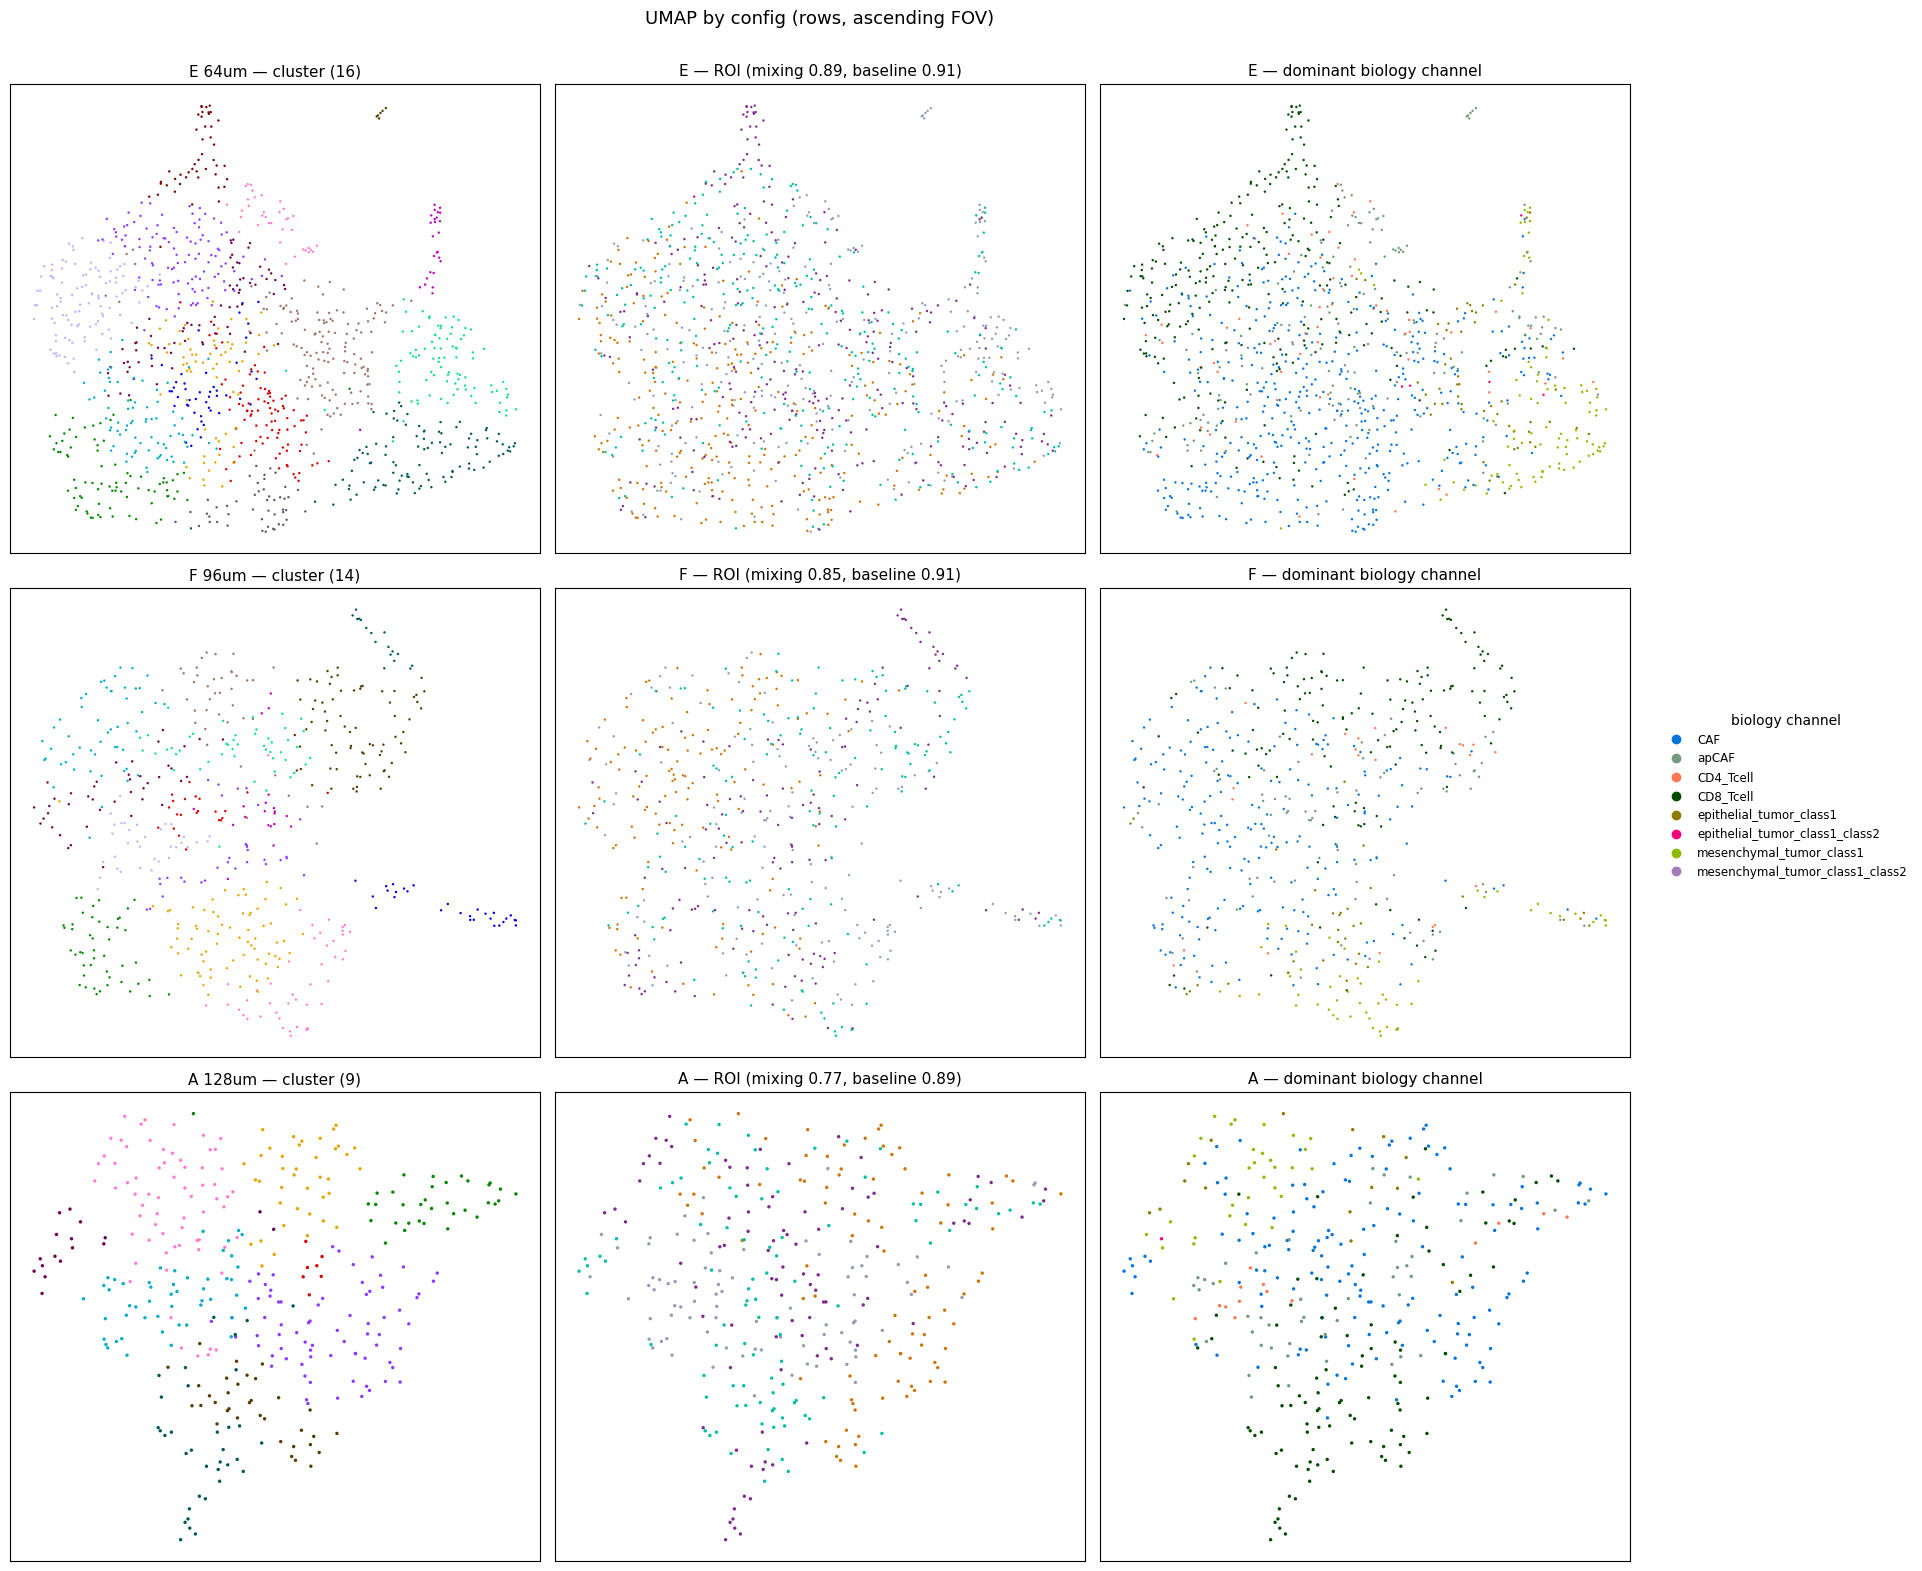

In [6]:
rc = imc_tm.roi_palette(ROIS)      # glasbey_dark, ROI slice
pal = imc_tm.palette()
fig, axes = plt.subplots(len(SERIES), 3, figsize=(16.5, 5.2 * len(SERIES)))
for i, n in enumerate(SERIES):
    u, lab = clus[n]["umap"], clus[n]["labels"]
    dom = np.array(imc_tm.BIOLOGY_TYPES)[bio_frac(res[n]["composition"]).argmax(axis=1)]
    s = 6 if len(u) < 500 else 3

    axes[i, 0].scatter(u[:, 0], u[:, 1], c=[COLORS[n][c] for c in lab], s=s, linewidths=0)
    axes[i, 0].set_title(f"{SHORT[n]} {imc_tm.sweep_spec(n)['fov_um']}um — cluster "
                         f"({len(np.unique(lab))})", fontsize=11)
    axes[i, 1].scatter(u[:, 0], u[:, 1], color=[rc[r] for r in res[n]["roi"]],
                       s=s, linewidths=0)
    axes[i, 1].set_title(f"{SHORT[n]} — ROI (mixing {met.loc[SHORT[n], 'roi_mixing']:.2f}, "
                         f"baseline {met.loc[SHORT[n], 'roimix_comp']:.2f})", fontsize=11)
    axes[i, 2].scatter(u[:, 0], u[:, 1], c=[pal[t] for t in dom], s=s, linewidths=0)
    axes[i, 2].set_title(f"{SHORT[n]} — dominant biology channel", fontsize=11)
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
h = [plt.Line2D([0], [0], marker="o", ls="", ms=6, color=pal[t], label=t)
     for t in imc_tm.BIOLOGY_TYPES]
fig.legend(handles=h, bbox_to_anchor=(1.005, 0.5), loc="center left", fontsize=8.5,
           frameon=False, title="biology channel")
plt.suptitle("UMAP by config (rows, ascending FOV)", y=1.004, fontsize=13)
plt.tight_layout()

## Clusters in tissue

The check that depends on no statistic at all. Contiguous blocks mean the window size
resolves real tissue domains; speckle means it does not.

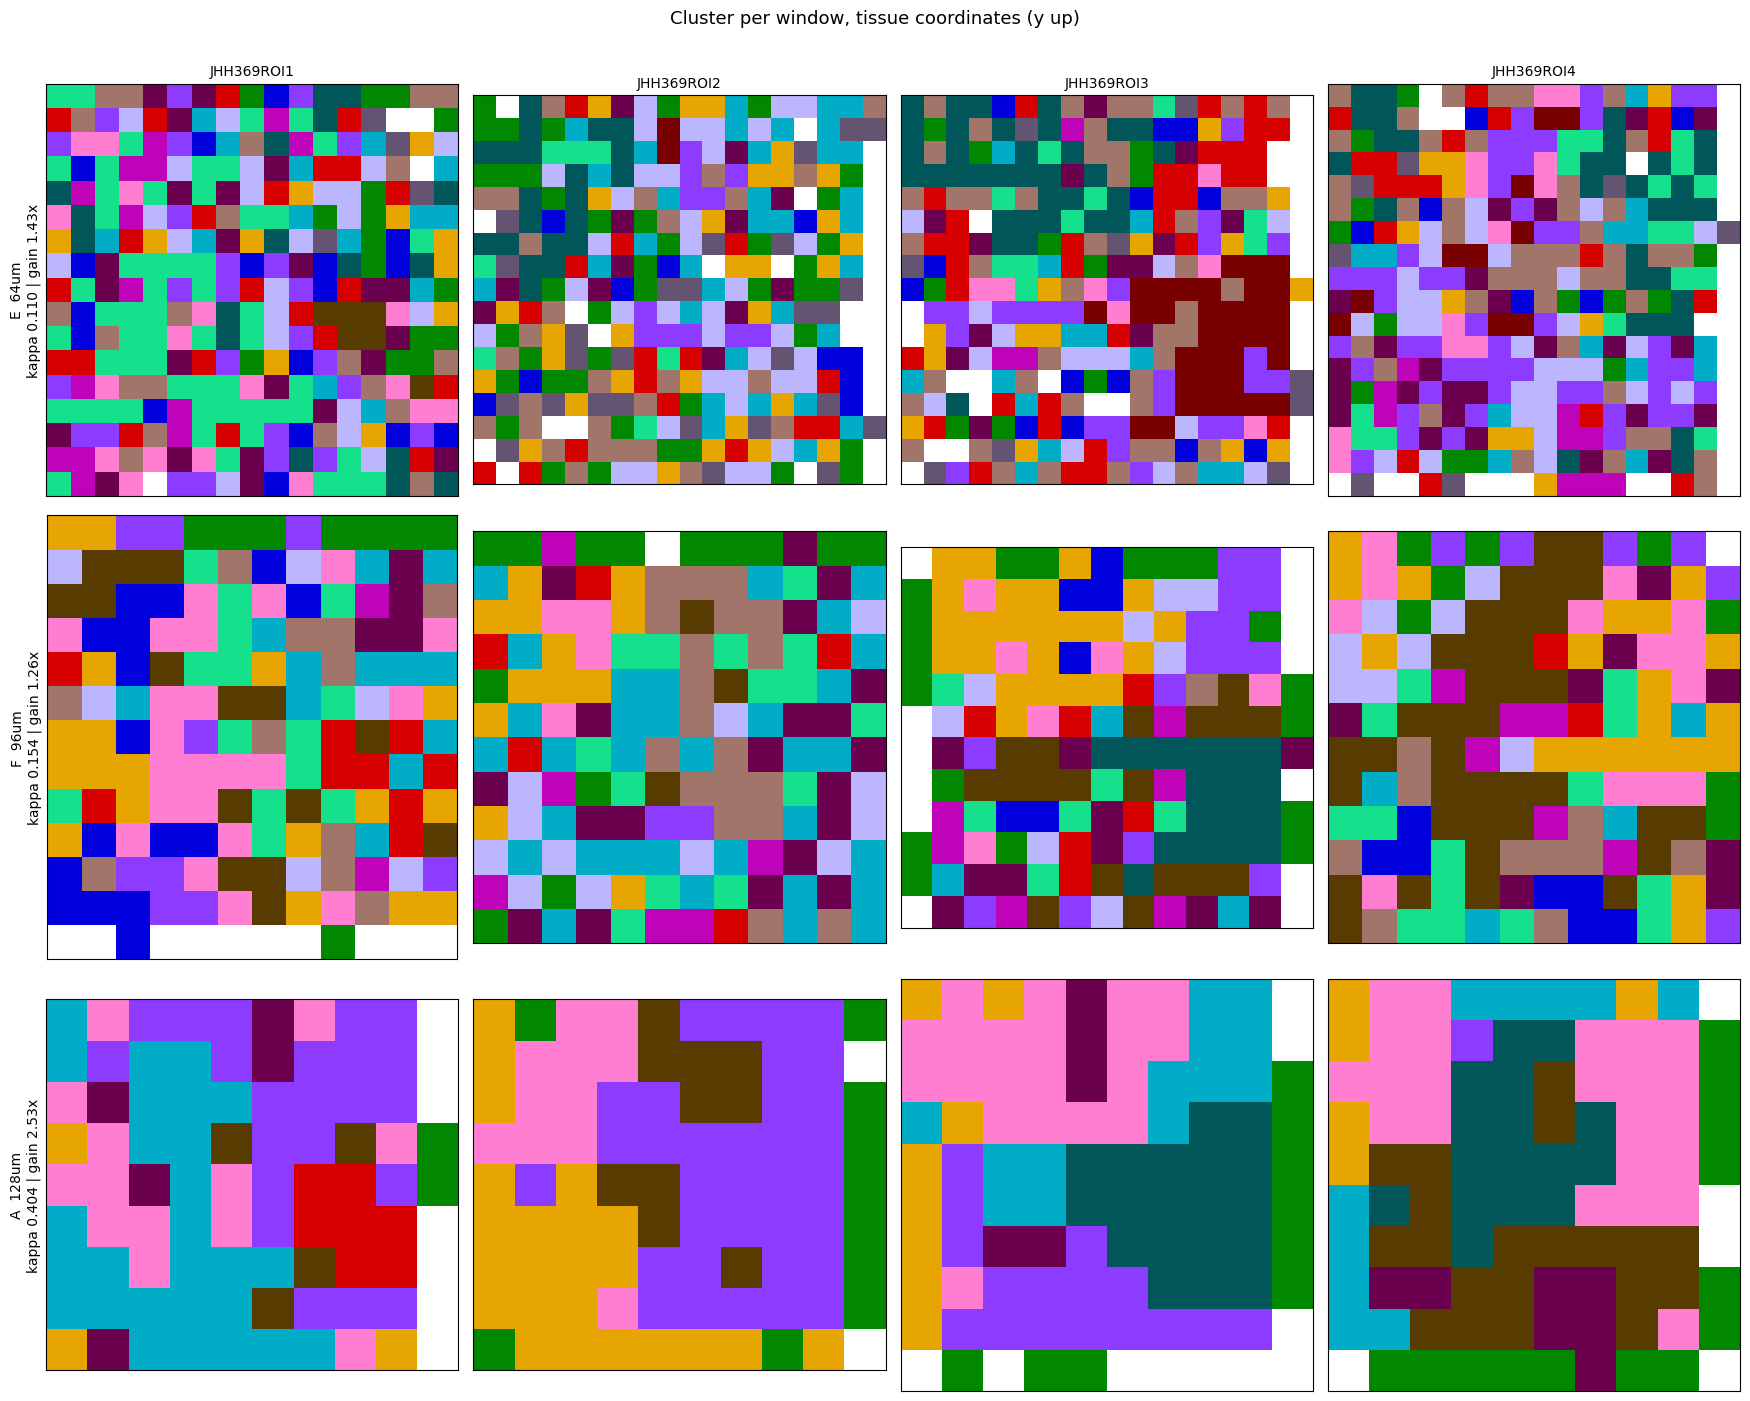

In [7]:
fig, axes = plt.subplots(len(SERIES), len(ROIS), figsize=(4.4 * len(ROIS), 4.7 * len(SERIES)))
for i, n in enumerate(SERIES):
    lab = clus[n]["labels"]
    fov = imc_tm.sweep_spec(n)["fov_um"]
    for j, r in enumerate(ROIS):
        m = res[n]["roi"] == r
        # true data-coordinate squares: a 64 um window is drawn 64 um wide, so the
        # three rows are directly comparable and contiguity reads honestly
        imc_tm.plot_window_map(axes[i, j], res[n]["centers_um"][m],
                               [COLORS[n][c] for c in lab[m]], fov)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if i == 0: axes[i, j].set_title(r, fontsize=10)
    axes[i, 0].set_ylabel(f"{SHORT[n]}  {imc_tm.sweep_spec(n)['fov_um']}um\n"
                          f"kappa {met.loc[SHORT[n], 'kappa']:.3f} | gain "
                          f"{met.loc[SHORT[n], 'gain_x']:.2f}x", fontsize=10)
plt.suptitle("Cluster per window, tissue coordinates (y up)", y=1.002, fontsize=13)
plt.tight_layout()

## What is each cluster made of?

In [8]:
profs = {}
for n in SERIES:
    comp = pd.DataFrame(res[n]["composition"], columns=imc_tm.CELL_TYPES)
    comp["cluster"] = clus[n]["labels"]
    prof = comp.groupby("cluster")[imc_tm.CELL_TYPES].mean()
    prof.insert(0, "n_windows", comp.groupby("cluster").size())
    prof.loc["ALL"] = [len(comp)] + list(res[n]["composition"].mean(axis=0))
    profs[n] = prof
    print(f"=== {n} ===")
    display(prof.round(3).style.background_gradient(axis=0, cmap="Blues", subset=imc_tm.CELL_TYPES))

=== E_fov64_px2.0 ===


,n_windows,CAF,apCAF,CD4_Tcell,CD8_Tcell,epithelial_tumor_class1,epithelial_tumor_class1_class2,mesenchymal_tumor_class1,mesenchymal_tumor_class1_class2,other_tissue,duct_filler
cluster,,,,,,,,,,,
0,91.000000,0.192000,0.101000,0.019000,0.025000,0.010000,0.007000,0.005000,0.001000,0.641000,0.000000
1,110.000000,0.110000,0.077000,0.068000,0.151000,0.007000,0.005000,0.000000,0.000000,0.580000,0.001000
2,80.000000,0.061000,0.016000,0.002000,0.011000,0.009000,0.000000,0.000000,0.000000,0.900000,0.000000
3,74.000000,0.066000,0.022000,0.016000,0.059000,0.002000,0.001000,0.000000,0.000000,0.833000,0.000000
4,65.000000,0.085000,0.026000,0.044000,0.114000,0.010000,0.006000,0.001000,0.000000,0.714000,0.000000
5,36.000000,0.070000,0.245000,0.083000,0.112000,0.005000,0.010000,0.001000,0.004000,0.465000,0.004000
6,73.000000,0.047000,0.080000,0.060000,0.062000,0.011000,0.006000,0.007000,0.001000,0.680000,0.047000
7,6.000000,0.058000,0.623000,0.000000,0.008000,0.000000,0.000000,0.000000,0.000000,0.311000,0.000000
8,103.000000,0.053000,0.015000,0.009000,0.009000,0.049000,0.002000,0.137000,0.009000,0.716000,0.002000


=== F_fov96_px2.0 ===


,n_windows,CAF,apCAF,CD4_Tcell,CD8_Tcell,epithelial_tumor_class1,epithelial_tumor_class1_class2,mesenchymal_tumor_class1,mesenchymal_tumor_class1_class2,other_tissue,duct_filler
cluster,,,,,,,,,,,
0,22.000000,0.062000,0.192000,0.004000,0.025000,0.017000,0.002000,0.005000,0.000000,0.693000,0.000000
1,32.000000,0.192000,0.146000,0.038000,0.062000,0.021000,0.012000,0.004000,0.001000,0.523000,0.002000
2,47.000000,0.094000,0.034000,0.016000,0.054000,0.022000,0.005000,0.021000,0.003000,0.751000,0.000000
3,52.000000,0.058000,0.023000,0.007000,0.033000,0.008000,0.002000,0.002000,0.000000,0.867000,0.000000
4,73.000000,0.071000,0.035000,0.020000,0.016000,0.061000,0.008000,0.060000,0.007000,0.721000,0.000000
5,45.000000,0.057000,0.052000,0.029000,0.050000,0.016000,0.004000,0.122000,0.027000,0.642000,0.001000
6,42.000000,0.067000,0.023000,0.030000,0.059000,0.015000,0.003000,0.001000,0.000000,0.803000,0.000000
7,73.000000,0.073000,0.094000,0.076000,0.162000,0.009000,0.005000,0.001000,0.000000,0.580000,0.000000
8,17.000000,0.090000,0.044000,0.088000,0.454000,0.009000,0.012000,0.000000,0.000000,0.304000,0.000000


=== A_fov128_px2.0 ===


,n_windows,CAF,apCAF,CD4_Tcell,CD8_Tcell,epithelial_tumor_class1,epithelial_tumor_class1_class2,mesenchymal_tumor_class1,mesenchymal_tumor_class1_class2,other_tissue,duct_filler
cluster,,,,,,,,,,,
0,7.000000,0.073000,0.279000,0.018000,0.023000,0.011000,0.002000,0.002000,0.000000,0.592000,0.000000
1,73.000000,0.088000,0.038000,0.021000,0.068000,0.010000,0.003000,0.003000,0.001000,0.767000,0.000000
2,34.000000,0.101000,0.044000,0.032000,0.101000,0.022000,0.009000,0.002000,0.000000,0.680000,0.008000
3,50.000000,0.113000,0.107000,0.066000,0.079000,0.014000,0.008000,0.025000,0.009000,0.561000,0.017000
4,39.000000,0.091000,0.022000,0.011000,0.039000,0.036000,0.004000,0.008000,0.001000,0.786000,0.002000
5,67.000000,0.082000,0.036000,0.016000,0.017000,0.039000,0.006000,0.074000,0.009000,0.722000,0.000000
6,17.000000,0.068000,0.031000,0.012000,0.035000,0.041000,0.011000,0.081000,0.011000,0.450000,0.260000
7,34.000000,0.064000,0.050000,0.034000,0.115000,0.006000,0.005000,0.003000,0.000000,0.720000,0.002000
8,35.000000,0.068000,0.078000,0.067000,0.248000,0.018000,0.012000,0.001000,0.000000,0.508000,0.000000


### Stacked bars

Left: all ten channels — `other_tissue` is ~67% of every window and swamps the stack.
Right: background dropped and the rest renormalised to classified biology.

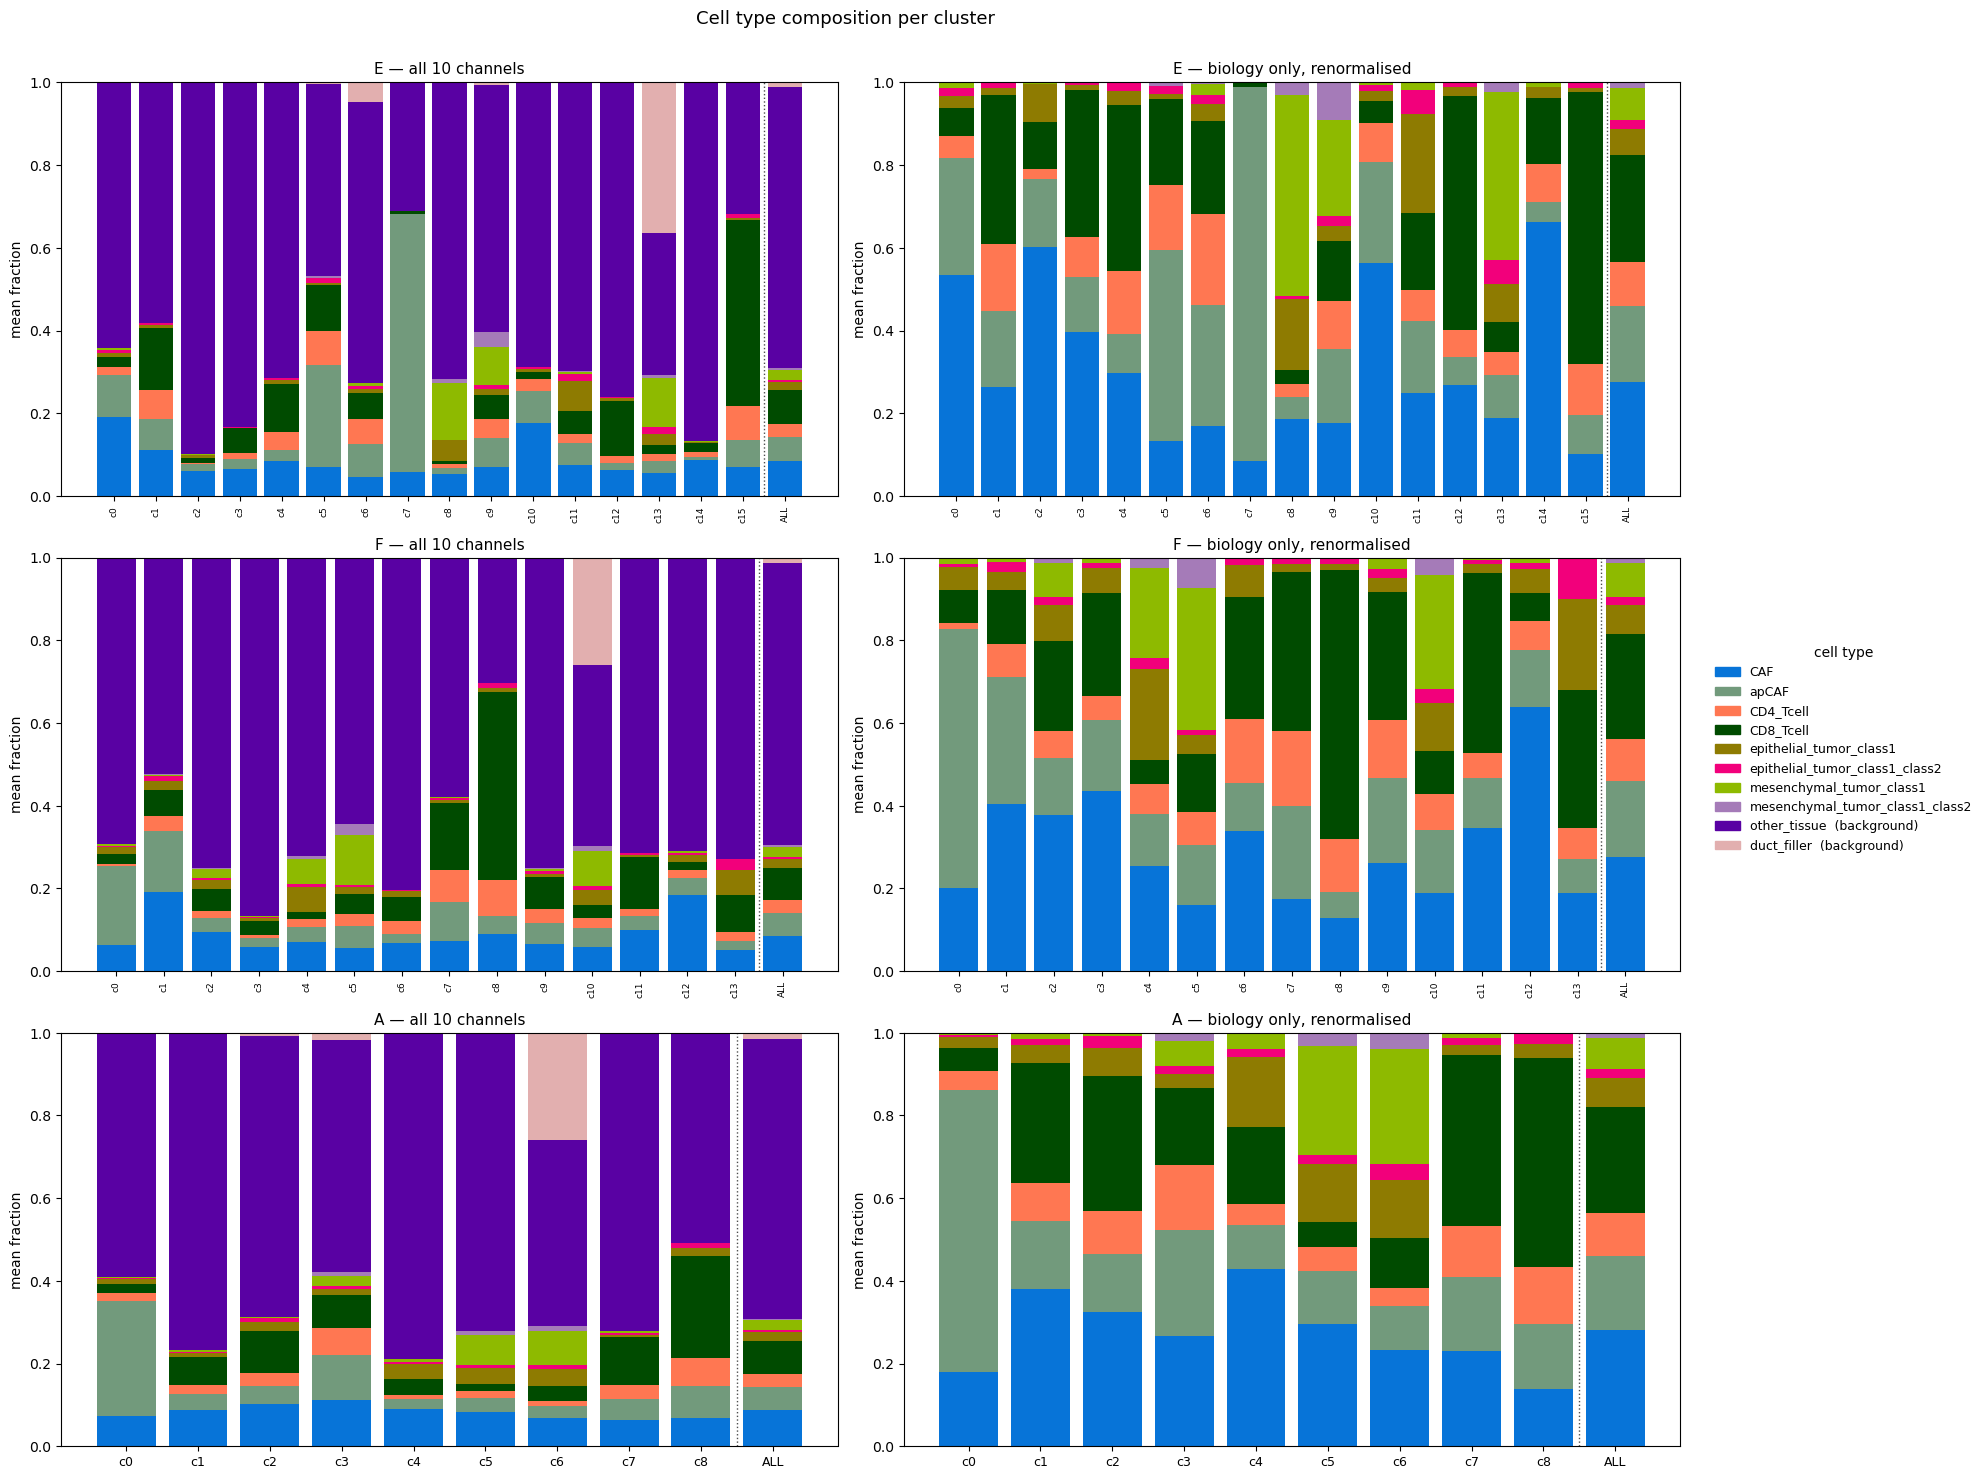

In [9]:
cell_colors = imc_tm.palette()
fig, axes = plt.subplots(len(SERIES), 2, figsize=(17, 4.9 * len(SERIES)))
for i, n in enumerate(SERIES):
    pb = profs[n].drop(index="ALL")[imc_tm.CELL_TYPES]
    pb.loc["ALL"] = res[n]["composition"].mean(axis=0)
    bio = pb[imc_tm.BIOLOGY_TYPES]; bio = bio.div(bio.sum(axis=1), axis=0)
    for ax, (tbl, cols, title) in zip(axes[i], [
            (pb, imc_tm.CELL_TYPES, f"{SHORT[n]} — all 10 channels"),
            (bio, imc_tm.BIOLOGY_TYPES, f"{SHORT[n]} — biology only, renormalised")]):
        bottom = np.zeros(len(tbl)); x = np.arange(len(tbl))
        for t in cols:
            ax.bar(x, tbl[t].values, bottom=bottom, color=cell_colors[t], width=0.82)
            bottom += tbl[t].values
        ax.set_xticks(x)
        ax.set_xticklabels([f"c{k}" if k != "ALL" else "ALL" for k in tbl.index],
                           fontsize=6.5 if len(tbl) > 12 else 9,
                           rotation=90 if len(tbl) > 12 else 0)
        ax.set_ylim(0, 1); ax.set_title(title, fontsize=11); ax.set_ylabel("mean fraction")
        ax.axvline(len(tbl) - 1.5, color="0.3", lw=1, ls=":")
handles = [plt.Rectangle((0, 0), 1, 1, color=cell_colors[t],
                         label=t + ("  (background)" if t in imc_tm.BACKGROUND_TYPES else ""))
           for t in imc_tm.CELL_TYPES]
fig.legend(handles=handles, bbox_to_anchor=(1.005, 0.5), loc="center left", fontsize=9,
           frameon=False, title="cell type")
plt.suptitle("Cell type composition per cluster", y=1.003, fontsize=13)
plt.tight_layout()

### Cluster by ROI, and the dominant channel

In [10]:
for n in SERIES:
    lab = clus[n]["labels"]
    comp = pd.DataFrame(res[n]["composition"], columns=imc_tm.CELL_TYPES); comp["cluster"] = lab
    print(f"=== {n} ===")
    ct = pd.crosstab(lab, res[n]["roi"]); ct["total"] = ct.sum(axis=1)
    print(ct.to_string())
    top = comp.groupby("cluster")[imc_tm.BIOLOGY_TYPES].mean().idxmax(axis=1)
    print("dominant BIOLOGY channel per cluster:")
    for c, t in top.items():
        frac = comp.groupby("cluster")[t].mean()[c]
        enrich = frac / max(res[n]["composition"][:, imc_tm.CELL_TYPES.index(t)].mean(), 1e-9)
        print(f"  cluster {c:<3} {t:<34s} {frac:.3f}   ({enrich:.1f}x cohort mean)")
    print()

=== E_fov64_px2.0 ===
col_0  JHH369ROI1  JHH369ROI2  JHH369ROI3  JHH369ROI4  total
row_0                                                       
0              22          16          35          18     91
1              25          11          24          50    110
2              15          42          10          13     80
3              14          34          13          13     74
4              11          30          14          10     65
5              17           0           7          12     36
6              23          12          13          25     73
7               6           0           0           0      6
8              17          21          34          31    103
9              57           7          10          16     90
10             17          10          13           6     46
11             21          28          45          44    138
12             22          37          14          30    103
13             14           0           3           9     26
14

## Border-cluster diagnostic

Windows on the outer ring sit partly outside the tissue. Because a border ring is
contiguous by construction, a cluster made of them inflates coherence while carrying no
biology. A cluster ≥80% border is the flag. None of these three configs produced one in
the six-way run — it is the 192 µm configs that do — but the overall border share still
differs, and it is reported here so the coherence numbers can be read with it in mind.

E_fov64_px2.0    overall  17.7%  |  >=80% border clusters: 0  |  worst 29.8%
F_fov96_px2.0    overall  27.0%  |  >=80% border clusters: 1  |  worst 85.1%
A_fov128_px2.0   overall  32.6%  |  >=80% border clusters: 1  |  worst 100.0%


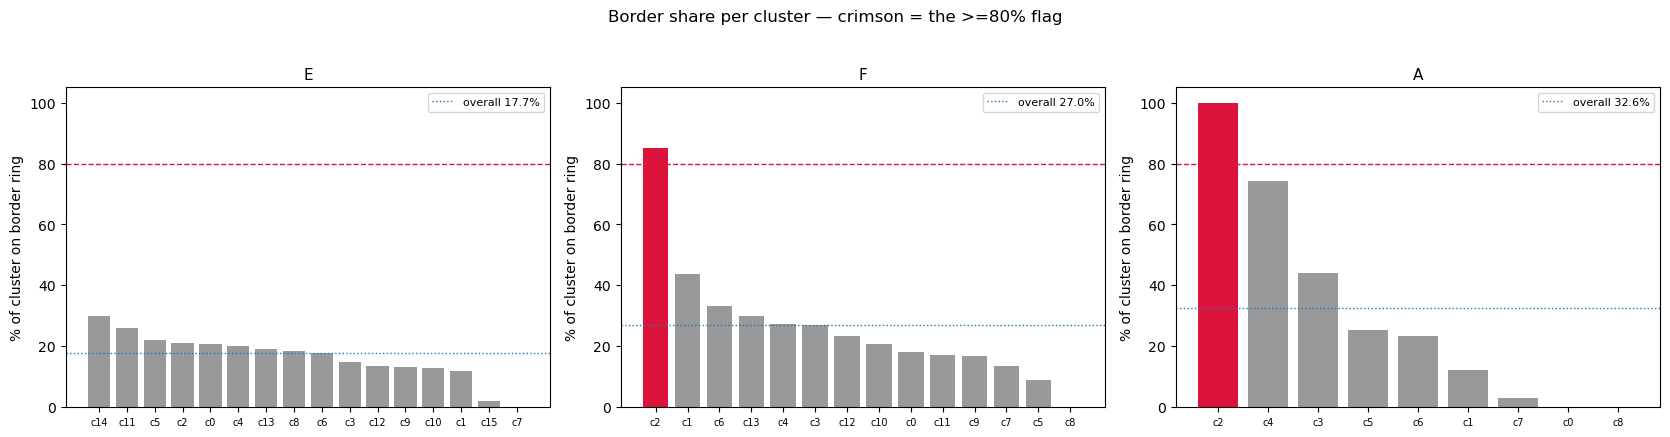

In [11]:
fig, axes = plt.subplots(1, len(SERIES), figsize=(5.6 * len(SERIES), 4.2))
for ax, n in zip(axes, SERIES):
    df, summary = imc_tm.border_cluster_report(res[n]["centers_um"], res[n]["roi"], clus[n]["labels"])
    df = df.sort_values("pct_border", ascending=False)
    print(f"{n:<16s} overall {summary['overall_border_pct']:5.1f}%  |  "
          f">=80% border clusters: {summary['n_border_clusters_ge80pct']}  |  "
          f"worst {summary['max_cluster_border_pct']:.1f}%")
    ax.bar(range(len(df)), df["pct_border"].values,
           color=["crimson" if v >= 80 else "0.6" for v in df["pct_border"]])
    ax.axhline(80, color="crimson", lw=1, ls="--")
    ax.axhline(summary["overall_border_pct"], color="C0", lw=1, ls=":",
               label=f"overall {summary['overall_border_pct']}%")
    ax.set_xticks(range(len(df))); ax.set_xticklabels([f"c{i}" for i in df.index], fontsize=7)
    ax.set_ylim(0, 105); ax.set_title(SHORT[n], fontsize=11); ax.legend(fontsize=8)
    ax.set_ylabel("% of cluster on border ring")
plt.suptitle("Border share per cluster — crimson = the >=80% flag", y=1.03, fontsize=12)
plt.tight_layout()

## Biology separation, with N held equal

Smaller windows produce more of them, and every measure of apparent separation improves
with more points. So each config is subsampled to the smallest N in the series and
re-clustered from scratch, several times.

`knn_r2_bio` is the one to trust most: it predicts a window's composition from its
neighbours in embedding space and never touches Leiden, so it is free of any clustering
artefact.

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

def knn_r2(feats, target, k=10):
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(feats))).fit(feats)
    pred = target[nn.kneighbors(feats)[1][:, 1:]].mean(axis=1)
    return 1.0 - ((target - pred) ** 2).sum() / ((target - target.mean(axis=0)) ** 2).sum()

def bio_score(feats, comp, labels):
    bf = bio_frac(comp)
    enr = [(bf[labels == c].mean(axis=0) / np.clip(bf.mean(axis=0), 1e-9, None)).max()
           for c in np.unique(labels)]
    return {"k_clusters": len(np.unique(labels)),
            "embed_sil": silhouette_score(feats, labels),
            "bio_sil": silhouette_score(bf, labels),
            "knn_r2_bio": knn_r2(feats, bf),
            "mean_max_enrich": float(np.mean(enr)),
            "n_clust_ge2x": int(sum(e >= 2.0 for e in enr))}

asis = pd.DataFrame([{"config": SHORT[n], "n": len(res[n]["roi"]),
                      **bio_score(res[n]["features"], res[n]["composition"], clus[n]["labels"])}
                     for n in SERIES]).set_index("config")
print("as-is -- N differs, this is what the UMAP panels show")
display(asis.style.format(precision=3))

N_TARGET, N_REP = min(len(res[n]["roi"]) for n in SERIES), 8
rows = []
for n in SERIES:
    reps = []
    for rep in range(N_REP):
        sel = np.random.default_rng(100 + rep).choice(len(res[n]["roi"]), N_TARGET, replace=False)
        f, c = res[n]["features"][sel], res[n]["composition"][sel]
        lab_ = imc_tm.cluster_embedding(f, n_neighbors=N_NEIGHBORS, resolution=RESOLUTION,
                                        seed=SEED)["labels"]
        reps.append(bio_score(f, c, lab_))
    rows.append({"config": SHORT[n], **pd.DataFrame(reps).mean().to_dict()})
matched = pd.DataFrame(rows).set_index("config")
print()
print(f"N matched at {N_TARGET} windows, re-clustered, mean of {N_REP} draws")
display(matched.style.format(precision=3))

as-is -- N differs, this is what the UMAP panels show


,n,k_clusters,embed_sil,bio_sil,knn_r2_bio,mean_max_enrich,n_clust_ge2x
config,,,,,,,
E,1134,16,0.028,-0.128,0.603,3.166,9
F,575,14,0.002,-0.114,0.597,2.593,8
A,356,9,-0.020,-0.068,0.466,2.321,4



N matched at 356 windows, re-clustered, mean of 8 draws


,k_clusters,embed_sil,bio_sil,knn_r2_bio,mean_max_enrich,n_clust_ge2x
config,,,,,,
E,9.750,-0.004,-0.049,0.530,2.789,5.875
F,10.250,-0.004,-0.076,0.574,2.411,5.875
A,10.125,-0.016,-0.089,0.467,2.351,4.875


## Reading it

1. **Gain panel** — the middle plot of the three-panel figure. If F lands near E rather
   than midway to A, arrangement is not something that improves smoothly with window
   size; there is a floor of cells below which the embedding cannot beat counting, and
   96 µm is still under it.
2. **Tissue maps** — the statistic-free check. Judge contiguity by eye across the rows.
3. **N-matched table** — apparent biological crispness at small FOV is largely a point-
   count effect. What survives matching is sharper per-cluster enrichment, which a
   sparse window gets nearly for free by being close to a composition measurement.
4. **ROI mixing vs its baseline** — read the departure, not the value. Sitting on the
   baseline means the embedding added nothing.

Caveats:

- **One patient, 200 epochs.** A screen, not converged models. The ranking is fair
  because the schedule is identical; absolute quality is not established.
- **Occupancy and FOV are confounded here by design.** All three share 2.0 µm/px, so a
  larger window is also a fuller one. Config C in the six-way sweep (192 µm at 3.0
  µm/px) is the lever that separates them: same network input as A, more tissue, coarser
  pixels.
- **The flat 10-cell filter favours large FOV.** It is 10% of expected occupancy at
  128 µm against 38% at 64 µm, so A keeps relatively more of its sparse and border
  windows. Any margin A shows here is an upper bound, not a fair estimate.
- **`cells_per_window` is a JHH369 average.** Cohort density spans 2,643–11,244
  cells/mm², so the threshold in cells — if that is what this is — will land at a
  different FOV in sparser patients.